In [327]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib

In [328]:
# Load Dataset
housing_price = pd.read_csv('created_house_price_prediction.csv')

In [330]:
# Data Exploration
housing_price.isnull().sum()
housing_price.head(200)
housing_price.tail(300)
housing_price.describe()
housing_price.values

array([[8000.0, 3.0, 2.0, ..., 2004.0, 'Lagos', 105402678.0],
       [8100.0, 2.0, 2.0, ..., 2013.0, 'Kaduna', 62530695.0],
       [8200.0, 2.0, 1.0, ..., 2023.0, 'Kano', 71488309.0],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(2050, 7), dtype=object)

In [331]:
# Data Cleaning
housing_price.dropna(inplace=True)
housing_price.duplicated()
housing_price.drop_duplicates(inplace=True)
housing_price = housing_price[housing_price['Area'] <= 12000]

In [332]:
# encode location
housing_price = pd.get_dummies(housing_price, columns=['Location'], drop_first=True)

In [333]:
# Define feature and target
X = housing_price.drop(columns=['Price']) # Feature
y = housing_price['Price'] # Target

In [334]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [335]:
# Create and Train model
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [336]:
# Predictions
y_predictions = model.predict(X_test)

In [337]:
# Evalueate model
mse = mean_squared_error(y_test,y_predictions)
print('Mean Square Error:', mse)
accuracy = r2_score(y_test,y_predictions)
print('Accuracy score',accuracy)

Mean Square Error: 7036723800381.848
Accuracy score 0.9802296264035113


In [338]:
# Check Model Equations
print('Slope of (m):', model.coef_)
print('Intercept of (b):',model.intercept_)

Slope of (m): [ 4.76803795e+03  2.00678441e+06  1.11847007e+06  2.02328050e+06
  2.86408331e+05 -2.98374200e+07 -2.37208862e+07 -1.78228962e+07
  1.26761367e+07]
Intercept of (b): -534421825.3339157


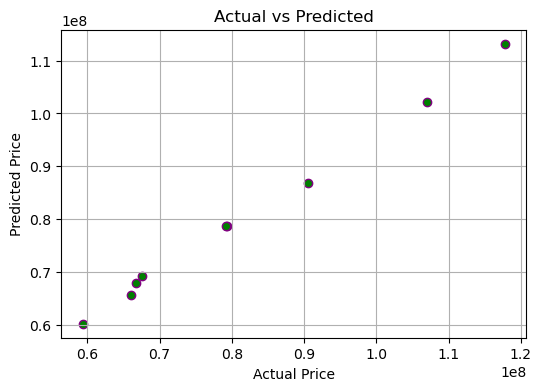

In [343]:
# Visualise graph
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_predictions,color='green',edgecolor='purple')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.grid()
plt.show()

In [352]:
# Predict new value
new_house = [[20000, 4, 3, 1, 2025, 1, 0, 0, 0]]  # depends on encoded columns
print("Price Prediction:", model.predict(new_house))

Price Prediction: [1.24484211e+08]


C:\Users\EASY BUSINESS TECH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [353]:
joblib.dump(model, "model.pkl")

['model.pkl']